# 13: Is It Really Reproducing?

This notebook reconstructs the scientific argument: visual recurrence is not reproduction; causal ancestry strengthens the reproduction claim; apparent flocking weakens under better controls. It executes a small causal example and validates canonical manuscript numbers from `data/digital-life/outlier.sqlite3` when that cache exists.


In [1]:
from pathlib import Path
import base64
import copy
import math
import sqlite3
from collections import Counter, defaultdict, deque
from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
BOOK_FIG_DIR = ROOT / "static" / "images" / "books" / "digital-life"
FIG_DIR = ROOT / "notebooks" / "generated-figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 180


In [2]:
OUTLIER_MAP = (
    "ERETQB4eHWkQ7xD4eYZosBQZFixOBHmtFeehExrKVhURLRAq"
    "GxeIlSO1JYZP6DRi69rop7TQCkvWTIag7kAS8g"
)
SEED = np.array([[0,1,0],[1,1,1],[0,0,1]], dtype=np.uint8)
OFFSETS = [(-1,-1,256),(-1,0,128),(-1,1,64),(0,-1,32),(0,0,16),(0,1,8),(1,-1,4),(1,0,2),(1,1,1)]

def decode_map_rule(encoded):
    padding = "=" * ((4 - len(encoded) % 4) % 4)
    raw = base64.b64decode(encoded + padding)
    bits = np.unpackbits(np.frombuffer(raw, dtype=np.uint8))
    if bits.size < 512:
        raise ValueError(f"MAP rule has only {bits.size} bits")
    return bits[:512].astype(np.uint8)

def index_to_grid(index):
    return np.array([(index >> shift) & 1 for shift in range(8, -1, -1)], dtype=np.uint8).reshape(3, 3)

def grid_to_index(grid):
    value = 0
    for bit in grid.reshape(-1):
        value = (value << 1) | int(bit)
    return value

def verify_rotational_symmetry(rule):
    for index in range(512):
        grid = index_to_grid(index)
        expected = int(rule[index])
        rotated = grid.copy()
        for _ in range(3):
            rotated = np.rot90(rotated)
            assert int(rule[grid_to_index(rotated)]) == expected

def make_world(size):
    world = np.zeros((size, size), dtype=np.uint8)
    r = size // 2 - 1
    c = size // 2 - 1
    world[r:r+3, c:c+3] = SEED
    return world

def neighborhood_codes(state):
    code = np.zeros(state.shape, dtype=np.uint16)
    for dr, dc, weight in OFFSETS:
        shifted = np.roll(np.roll(state, -dr, axis=0), -dc, axis=1)
        code |= shifted.astype(np.uint16) * np.uint16(weight)
    return code

def outlier_step(state, rule):
    return rule[neighborhood_codes(state)]


In [3]:
EXPERIMENT = {"canonical_grid": 512, "canonical_generations": 1600, "boundary": "periodic", "db": str(ROOT / "data" / "digital-life" / "outlier.sqlite3"), "pair_radius": 96.0, "flow_radius": 48.0, "density_radius": 32.0, "flow_min_neighbors": 3, "time_bin_width": 25, "distance_edges": [0,4,8,12,16,24,32,48,64,96], "max_matches_per_stratum": 5000, "seed": 42, "support_thresholds": [50,100,250,500]}
EXPECTED = {"clusters": 138891, "causal_edges": 196466, "c2_occurrences": 144, "visible_c2_return_edges": 99, "motion_observations": 633808, "pair_records": 2617077, "matched_pairs_per_group": 64948, "matched_strata": 659, "matched_pooled_effect": -0.007067, "bootstrap_low": -0.066450, "bootstrap_high": 0.012172}
EXPERIMENT, EXPECTED


({'canonical_grid': 512,
  'canonical_generations': 1600,
  'boundary': 'periodic',
  'db': 'C:\\Projects\\working-book\\data\\digital-life\\outlier.sqlite3',
  'pair_radius': 96.0,
  'flow_radius': 48.0,
  'density_radius': 32.0,
  'flow_min_neighbors': 3,
  'time_bin_width': 25,
  'distance_edges': [0, 4, 8, 12, 16, 24, 32, 48, 64, 96],
  'max_matches_per_stratum': 5000,
  'seed': 42,
  'support_thresholds': [50, 100, 250, 500]},
 {'clusters': 138891,
  'causal_edges': 196466,
  'c2_occurrences': 144,
  'visible_c2_return_edges': 99,
  'motion_observations': 633808,
  'pair_records': 2617077,
  'matched_pairs_per_group': 64948,
  'matched_strata': 659,
  'matched_pooled_effect': -0.007067,
  'bootstrap_low': -0.06645,
  'bootstrap_high': 0.012172})

## Published rule verification


In [4]:
RULE = decode_map_rule(OUTLIER_MAP)
assert RULE.shape == (512,)
assert int(RULE.sum()) == 220
verify_rotational_symmetry(RULE)
{"rule_entries": int(RULE.size), "live_outputs": int(RULE.sum()), "dead_outputs": int(512 - RULE.sum())}


{'rule_entries': 512, 'live_outputs': 220, 'dead_outputs': 292}

## Small executable causal mechanism

This is not the canonical 512x512 run. It is a compact demonstration of the counterfactual cell test used to build causal edges.


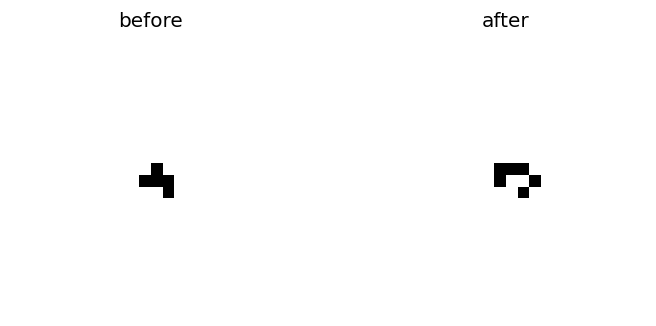

{'live_before': 5,
 'live_after': 6,
 'positive_counterfactual_edges': 11,
 'first_edges': [((12, 11), (11, 11)),
  ((12, 12), (11, 11)),
  ((12, 12), (11, 12)),
  ((11, 12), (11, 13)),
  ((12, 12), (11, 13)),
  ((11, 12), (12, 11)),
  ((12, 12), (12, 11)),
  ((12, 13), (12, 14))]}

In [5]:
def dependency_edges_one_step(before, rule):
    after = outlier_step(before, rule); code = neighborhood_codes(before); edges=[]
    for row, col in np.argwhere(after == 1):
        observed = int(rule[int(code[row, col])])
        for dr, dc, weight in OFFSETS:
            pr=(row+dr)%before.shape[0]; pc=(col+dc)%before.shape[1]
            if before[pr,pc] and observed and int(rule[int(code[row,col]) ^ weight]) == 0:
                edges.append(((int(pr),int(pc)), (int(row),int(col))))
    return after, edges
before = make_world(24); after, edges = dependency_edges_one_step(before, RULE)
fig, axes = plt.subplots(1,2,figsize=(7,3)); axes[0].imshow(before,cmap="binary"); axes[0].set_title("before"); axes[1].imshow(after,cmap="binary"); axes[1].set_title("after"); [ax.axis("off") for ax in axes]; plt.show()
{"live_before": int(before.sum()), "live_after": int(after.sum()), "positive_counterfactual_edges": len(edges), "first_edges": edges[:8]}


## Canonical cache validation

If the SQLite specimen exists, this cell compares notebook-read values against the manuscript. If absent, it reports the exact rebuild path instead of pretending to recompute the expensive dataset.


In [6]:
db_path = Path(EXPERIMENT["db"])
validation = {"cache_present": db_path.exists(), "db_path": str(db_path)}
if db_path.exists():
    conn = sqlite3.connect(db_path)
    run = conn.execute("SELECT id, size, generations, status FROM experiment_runs WHERE status='complete' ORDER BY id DESC LIMIT 1").fetchone()
    validation["latest_run"] = run
    if run:
        run_id = int(run[0])
        queries = {
            "clusters": "SELECT COUNT(*) FROM clusters WHERE run_id=?",
            "causal_edges": "SELECT COUNT(*) FROM causal_edges WHERE run_id=?",
            "c2_occurrences": "SELECT COUNT(*) FROM c2_occurrences WHERE run_id=?",
            "motion_observations": "SELECT COUNT(*) FROM motion_points WHERE run_id=?",
            "pair_records": "SELECT COUNT(*) FROM ch13_pair_records WHERE run_id=?",
        }
        for key, sql in queries.items():
            try:
                value = int(conn.execute(sql, (run_id,)).fetchone()[0])
                validation[key] = {"observed": value, "expected": EXPECTED.get(key), "matches": value == EXPECTED.get(key)}
            except sqlite3.Error as exc:
                validation[key] = {"error": str(exc), "expected": EXPECTED.get(key)}
        try:
            value = int(conn.execute("SELECT COUNT(*) FROM c2_return_edges WHERE run_id=?", (run_id,)).fetchone()[0])
            validation["visible_c2_return_edges"] = {"observed": value, "expected": EXPECTED["visible_c2_return_edges"], "matches": value == EXPECTED["visible_c2_return_edges"]}
        except sqlite3.Error as exc:
            validation["visible_c2_return_edges"] = {"error": str(exc), "expected": EXPECTED["visible_c2_return_edges"]}
    conn.close()
else:
    validation["rebuild_path"] = [
        "python scripts/books/digital-life/ch11_outlier_radial_flocking.py --size 512 --generations 1600",
        "python scripts/books/digital-life/ch11_outlier_local_flow.py",
        "python scripts/books/digital-life/ch11_outlier_causal_motion.py",
        "python scripts/books/digital-life/ch11_outlier_distance_matched.py",
        "python scripts/books/digital-life/ch13_outlier_overlap_analysis.py",
    ]
validation


{'cache_present': False,
 'db_path': 'C:\\Projects\\working-book\\data\\digital-life\\outlier.sqlite3',
 'rebuild_path': ['python scripts/books/digital-life/ch11_outlier_radial_flocking.py --size 512 --generations 1600',
  'python scripts/books/digital-life/ch11_outlier_local_flow.py',
  'python scripts/books/digital-life/ch11_outlier_causal_motion.py',
  'python scripts/books/digital-life/ch11_outlier_distance_matched.py',
  'python scripts/books/digital-life/ch13_outlier_overlap_analysis.py']}

## Research sequence and bounded result

Visual impression -> moving structures -> velocity alignment -> shuffled control -> radial-flow control -> causal-family hypothesis -> estimator confound -> pair-excluded flow -> distance/time/density matching -> common-support audit -> smaller bounded claim.

The manuscript's final reported common-support result is: matched pooled effect `-0.007067`, equal-stratum bootstrap interval `[-0.066450, +0.012172]`, with `64,948` matched pairs per group over `659` strata. The upper bound is about `1.9%` of the original `0.645` apparent family gap.

## Provenance

**Book chapter**: `content/books/digital-life/13-is-it-really-reproducing/index.md`

**Research scripts used**: `ch10_outlier_lineage.py`, `ch11_outlier_radial_flocking.py`, `ch11_outlier_local_flow.py`, `ch11_outlier_causal_motion.py`, `ch11_outlier_distance_matched.py`, `ch13_outlier_overlap_analysis.py`

**Book figures referenced/reproduced when cache exists**: `ch10-outlier-causal-lineage.png`, `ch10-outlier-flocking-test.png`, `ch11-outlier-radial-family-flocking.png`, `ch11-outlier-family-coverage.png`, `ch11-outlier-relatedness-coherence.png`, `ch11-outlier-distance-matched-coherence.png`, `ch11-outlier-distance-matched-effect-by-distance.png`.

## What was not demonstrated

This notebook does not independently rebuild the full canonical SQLite specimen when it is absent, because that is the heavy research pipeline. It does not establish classical flocking, natural individuality, open-ended evolution, or life.
